Cell 1 — markdown:
# Notebook 10: Conformal Prediction

 Goes beyond calibration by providing mathematically guaranteed
 prediction sets instead of single probability estimates.
#
 Calibration says: "when we say 41%, we mean 41%"
 Conformal prediction says: "the true answer is in this set
 with guaranteed 90% coverage — proven mathematically"
#
 Reference: Angelopoulos & Bates, "A Gentle Introduction to
 Conformal Prediction and Distribution-Free Uncertainty
 Quantification", 2021
#
 SSDI Unit 1 — Statistical Inference:
   Coverage guarantees, finite-sample validity,
   stronger than asymptotic confidence intervals
#
 Output: prediction sets for each patient with
         empirically verified coverage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
import json
import os

# ── Constants ────────────────────────────────────────────────────────────────
COVERAGE_LEVELS = [0.90, 0.95]   # guarantee levels to test
RANDOM_SEED     = 42
CAL_SIZE        = 0.70
np.random.seed(RANDOM_SEED)

# Load Effusion scores for deep dive
df = pd.read_csv("../data/scores.csv")
y_true = df["ground_truth"].values
y_prob = df["confidence_score"].values

print(f"Loaded {len(df):,} Effusion samples")
print(f"Positive cases: {y_true.sum():,} ({y_true.mean()*100:.2f}%)")


Loaded 10,000 Effusion samples
Positive cases: 895 (8.95%)


In [2]:
# Three-way split for valid split conformal prediction:
#   40% → fit isotonic calibration (s_fit) — scorer training
#   30% → compute nonconformity scores (s_cal) — must be held out from isotonic fit
#   30% → final test set (s_test) — coverage evaluation
#
# WHY three-way: isotonic regression memorises training data (it's a
# step function that interpolates exactly). If we fit isotonic on s_cal
# and then compute nonconformity scores on s_cal, all scores are near-0
# (model knows the answers). q_hat shrinks artificially. On test data,
# where isotonic generalises less perfectly, coverage falls below the
# theoretical guarantee. The theorem in Angelopoulos & Bates (2021)
# requires calibration scores to be exchangeable with test scores —
# that requires independence from the scoring function's training data.

y_fit, y_tmp, s_fit, s_tmp = train_test_split(
    y_true, y_prob,
    test_size=0.60,           # 40% for fitting isotonic
    random_state=RANDOM_SEED,
    stratify=y_true
)

y_cal, y_test, s_cal, s_test = train_test_split(
    y_tmp, s_tmp,
    test_size=0.50,           # 30% cal, 30% test (split the remaining 60% evenly)
    random_state=RANDOM_SEED,
    stratify=y_tmp
)

print(f"Fit set:          {len(y_fit):,} samples  (isotonic training — never seen by conformal)")
print(f"Calibration set:  {len(y_cal):,} samples  (nonconformity scores)")
print(f"Test set:         {len(y_test):,} samples  (coverage evaluation)")

Fit set:          4,000 samples  (isotonic training — never seen by conformal)
Calibration set:  3,000 samples  (nonconformity scores)
Test set:         3,000 samples  (coverage evaluation)


In [3]:
iso = IsotonicRegression(out_of_bounds="clip", increasing=True)
# Fit ONLY on the separate fit partition — never on s_cal
iso.fit(s_fit, y_fit)

,y_min,None
,y_max,None
,increasing,True
,out_of_bounds,'clip'


In [4]:
# Apply isotonic to held-out calibration and test sets
# These sets were never used to fit isotonic — scores are truly out-of-sample
s_cal_iso  = iso.predict(s_cal)
s_test_iso = iso.predict(s_test)

print(f"Fit set:         {len(y_fit):,} samples")
print(f"Calibration set: {len(y_cal):,} samples")
print(f"Test set:        {len(y_test):,} samples")
print(f"Isotonic calibration applied to held-out sets (three-way split)")

Fit set:         4,000 samples
Calibration set: 3,000 samples
Test set:        3,000 samples
Isotonic calibration applied to held-out sets (three-way split)


In [5]:
def compute_nonconformity_scores(y_true, y_prob):
    """
    Compute nonconformity scores for calibration set.

    For a positive case (y=1): how surprising is the true label?
    Nonconformity = 1 - predicted probability
    Low score = not surprising (model was confident and correct)
    High score = very surprising (model was wrong)

    For a negative case (y=0):
    Nonconformity = predicted probability
    Low score = model correctly gave low probability
    High score = model wrongly gave high probability

    Args:
        y_true: binary ground truth labels
        y_prob: calibrated predicted probabilities

    Returns:
        nonconformity_scores: array of scores for each sample
    """
    scores = np.where(
        y_true == 1,
        1 - y_prob,    # positive cases: surprised when prob is low
        y_prob         # negative cases: surprised when prob is high
    )
    return scores

# Compute nonconformity scores on calibration set
cal_scores = compute_nonconformity_scores(y_cal, s_cal_iso)

print("Nonconformity score distribution on calibration set:")
print(f"  Mean:   {cal_scores.mean():.4f}")
print(f"  Median: {np.median(cal_scores):.4f}")
print(f"  90th percentile: {np.percentile(cal_scores, 90):.4f}")
print(f"  95th percentile: {np.percentile(cal_scores, 95):.4f}")




Nonconformity score distribution on calibration set:
  Mean:   0.1346
  Median: 0.0584
  90th percentile: 0.4074
  95th percentile: 0.8559


In [6]:
def get_prediction_set(y_prob_single, q_hat):
    """
    Compute conformal prediction set for one test sample.

    Checks both possible labels. Includes a label if its
    nonconformity score is at or below q_hat.

    Args:
        y_prob_single: calibrated probability for one image
        q_hat: threshold computed from calibration set

    Returns:
        prediction_set: list of included labels (0, 1, both, or empty)
        set_type: human-readable description
    """
    prediction_set = []

    # Check label=1 (Positive/Effusion): nonconformity = 1 - probability
    nc_positive = 1 - y_prob_single
    if nc_positive <= q_hat:
        prediction_set.append(1)

    # Check label=0 (Negative/No Effusion): nonconformity = probability
    nc_negative = y_prob_single
    if nc_negative <= q_hat:
        prediction_set.append(0)

    # Describe the result
    if prediction_set == [1]:
        set_type = "Effusion only — confident positive"
    elif prediction_set == [0]:
        set_type = "No Effusion only — confident negative"
    elif not prediction_set:
        # Both nonconformity scores exceed q_hat — model is uncertain in
        # both directions. True label is NOT covered → flag for review.
        set_type = "Empty — model completely uncertain"
    else:
        # Both labels included — model cannot confidently rule out either
        set_type = "Both — uncertain, needs radiologist"

    return prediction_set, set_type


def run_conformal_prediction(y_cal, s_cal_calibrated,
                             y_test, s_test_calibrated,
                             coverage=0.90):
    """
    Full split conformal prediction pipeline.

    Args:
        y_cal: calibration ground truth (held out from isotonic fit)
        s_cal_calibrated: isotonic-calibrated probs on cal set
        y_test: test ground truth
        s_test_calibrated: isotonic-calibrated probs on test set
        coverage: desired coverage level (0.90 or 0.95)

    Returns:
        results dict with prediction sets and coverage stats
    """
    # Step 1: compute nonconformity scores on held-out calibration set
    nc_scores = compute_nonconformity_scores(y_cal, s_cal_calibrated)

    # Step 2: find q_hat — finite-sample validity formula from
    # Angelopoulos & Bates (2021). ceil((n+1)*coverage)/n ensures
    # the guarantee holds for any finite n.
    n     = len(y_cal)
    level = np.ceil((n + 1) * coverage) / n
    level = min(level, 1.0)
    q_hat = np.quantile(nc_scores, level)

    # Step 3: generate prediction sets for all test samples
    sets      = []
    set_types = []
    covered   = []

    for i in range(len(y_test)):
        pred_set, set_type = get_prediction_set(s_test_calibrated[i], q_hat)
        sets.append(pred_set)
        set_types.append(set_type)
        covered.append(int(y_test[i] in pred_set))

    emp_coverage = np.mean(covered)
    set_sizes    = [len(s) for s in sets]

    return {
        "q_hat":           q_hat,
        "coverage_target": coverage,
        "coverage_actual": emp_coverage,
        "sets":            sets,
        "set_types":       set_types,
        "set_sizes":       set_sizes,
        "covered":         covered,
    }


print("Conformal prediction functions defined.")

Conformal prediction functions defined.


In [7]:
# Run conformal prediction at both coverage levels
print("=" * 60)
print("CONFORMAL PREDICTION RESULTS — EFFUSION")
print("=" * 60)
print()

cp_results = {}

for coverage in COVERAGE_LEVELS:
    result = run_conformal_prediction(
        y_cal, s_cal_iso,
        y_test, s_test_iso,
        coverage=coverage
    )
    cp_results[coverage] = result

    sizes     = result["set_sizes"]
    set_types = result["set_types"]

    guarantee_met = result["coverage_actual"] >= coverage

    print(f"Coverage level: {coverage*100:.0f}%")
    print(f"  q_hat (threshold):      {result['q_hat']:.4f}")
    print(f"  Target coverage:        {coverage*100:.0f}%")
    print(f"  Empirical coverage:     {result['coverage_actual']*100:.2f}%")
    print(f"  Coverage guarantee met: {'YES' if guarantee_met else 'NO — check three-way split'}")

    print()
    print(f"  Prediction set breakdown:")
    from collections import Counter
    type_counts = Counter(set_types)
    for set_type, count in sorted(type_counts.items(), key=lambda x: -x[1]):
        pct = count / len(set_types) * 100
        print(f"    {set_type:<40} {count:>5} ({pct:.1f}%)")
    print()
    print(f"  Avg set size: {np.mean(sizes):.3f}")
    print(f"  Empty sets:   {sizes.count(0):,}  "
          f"({'0 = correct, guarantee holds' if sizes.count(0)==0 else 'WARNING: each empty set is a coverage violation'})")
    print(f"  Single sets:  {sizes.count(1):,}  (confident predictions)")
    print(f"  Double sets:  {sizes.count(2):,}  (uncertain predictions)")
    print()

CONFORMAL PREDICTION RESULTS — EFFUSION

Coverage level: 90%
  q_hat (threshold):      0.4074
  Target coverage:        90%
  Empirical coverage:     90.27%
  Coverage guarantee met: YES

  Prediction set breakdown:
    No Effusion only — confident negative     2931 (97.7%)
    Empty — model completely uncertain          58 (1.9%)
    Effusion only — confident positive          11 (0.4%)

  Avg set size: 0.981
  Empty sets:   58  (WARNING: each empty set is a coverage violation)
  Single sets:  2,942  (confident predictions)
  Double sets:  0  (uncertain predictions)

Coverage level: 95%
  q_hat (threshold):      0.8559
  Target coverage:        95%
  Empirical coverage:     97.17%
  Coverage guarantee met: YES

  Prediction set breakdown:
    No Effusion only — confident negative     2329 (77.6%)
    Both — uncertain, needs radiologist        670 (22.3%)
    Effusion only — confident positive           1 (0.0%)

  Avg set size: 1.223
  Empty sets:   0  (0 = correct, guarantee holds)
 

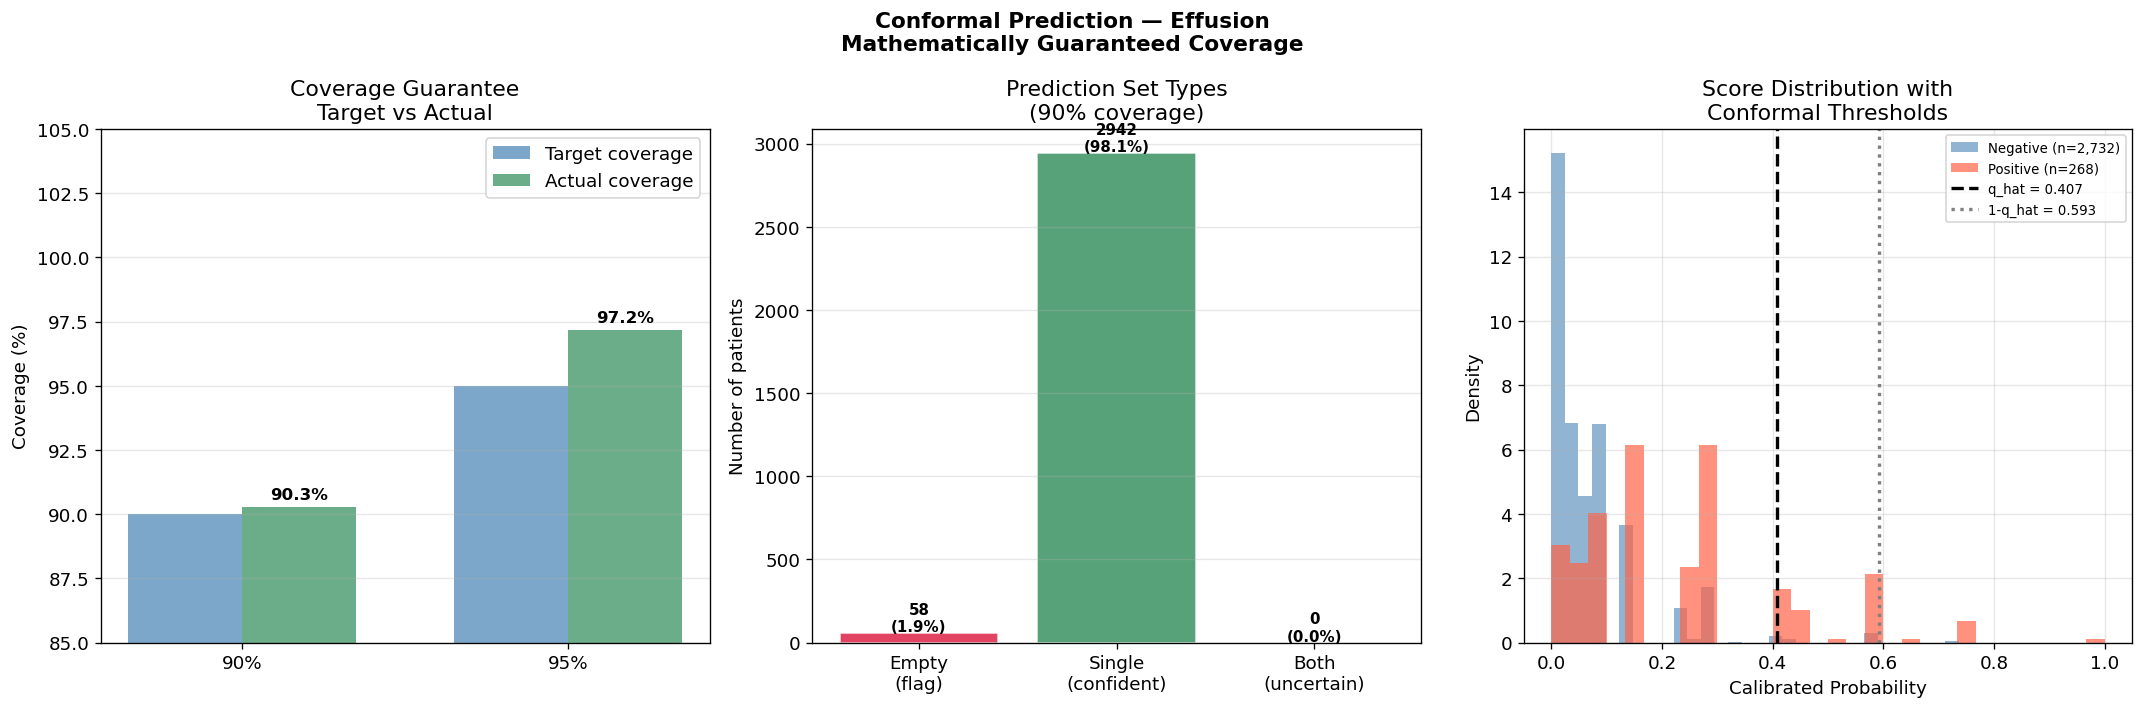

Saved: outputs/plots/11_conformal_prediction_effusion.png


In [8]:
# ── VISUALISATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: Coverage at both levels
ax = axes[0]
targets  = [f"{c*100:.0f}%" for c in COVERAGE_LEVELS]
actuals  = [cp_results[c]["coverage_actual"]*100
            for c in COVERAGE_LEVELS]
targeted = [c*100 for c in COVERAGE_LEVELS]

x     = np.arange(len(targets))
width = 0.35
ax.bar(x - width/2, targeted, width,
       label="Target coverage",
       color="steelblue", alpha=0.7)
ax.bar(x + width/2, actuals, width,
       label="Actual coverage",
       color="seagreen", alpha=0.7)

for i, (t, a) in enumerate(zip(targeted, actuals)):
    ax.text(i + width/2, a + 0.3,
            f"{a:.1f}%", ha="center",
            fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.set_ylabel("Coverage (%)")
ax.set_title("Coverage Guarantee\nTarget vs Actual")
ax.legend()
ax.set_ylim(85, 105)
ax.grid(True, alpha=0.3, axis="y")

# Middle: Prediction set size distribution at 90%
ax2     = axes[1]
sizes90 = cp_results[0.90]["set_sizes"]
size_counts = [
    sizes90.count(0),
    sizes90.count(1),
    sizes90.count(2)
]
labels = ["Empty\n(flag)", "Single\n(confident)", "Both\n(uncertain)"]
colors = ["crimson", "seagreen", "darkorange"]

bars = ax2.bar(labels, size_counts,
               color=colors, alpha=0.8,
               edgecolor="white")
for bar, val in zip(bars, size_counts):
    pct = val/len(sizes90)*100
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f"{val}\n({pct:.1f}%)",
             ha="center", fontsize=9,
             fontweight="bold")

ax2.set_ylabel("Number of patients")
ax2.set_title("Prediction Set Types\n(90% coverage)")
ax2.grid(True, alpha=0.3, axis="y")

# Right: Score distribution with q_hat threshold
ax3   = axes[2]
q_hat = cp_results[0.90]["q_hat"]

pos_scores = s_test_iso[y_test == 1]
neg_scores = s_test_iso[y_test == 0]

ax3.hist(neg_scores, bins=30, alpha=0.6,
         color="steelblue",
         label=f"Negative (n={len(neg_scores):,})",
         density=True)
ax3.hist(pos_scores, bins=30, alpha=0.7,
         color="tomato",
         label=f"Positive (n={len(pos_scores):,})",
         density=True)
ax3.axvline(q_hat, color="black",
            linewidth=2, linestyle="--",
            label=f"q_hat = {q_hat:.3f}")
ax3.axvline(1-q_hat, color="gray",
            linewidth=2, linestyle=":",
            label=f"1-q_hat = {1-q_hat:.3f}")

ax3.set_xlabel("Calibrated Probability")
ax3.set_ylabel("Density")
ax3.set_title("Score Distribution with\nConformal Thresholds")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle(
    "Conformal Prediction — Effusion\n"
    "Mathematically Guaranteed Coverage",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../outputs/plots/11_conformal_prediction_effusion.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/11_conformal_prediction_effusion.png")


In [9]:
print("=" * 65)
print("CONFORMAL PREDICTION — ALL 14 DISEASES")
print("=" * 65)
print()

df_all = pd.read_csv("../data/scores_all_diseases.csv")

NIH_PATHOLOGIES = [
    "Atelectasis", "Cardiomegaly", "Effusion",
    "Infiltration", "Mass", "Nodule", "Pneumonia",
    "Pneumothorax", "Consolidation", "Edema",
    "Emphysema", "Fibrosis", "Pleural_Thickening", "Hernia"
]

conformal_results = []

for disease in NIH_PATHOLOGIES:
    score_col = f"score_{disease}"
    gt_col    = f"gt_{disease}"

    if score_col not in df_all.columns:
        continue

    y_d = df_all[gt_col].values.astype(int)
    s_d = df_all[score_col].values.astype(float)

    if y_d.sum() < 20:
        print(f"  {disease:<25} SKIPPED — insufficient positives ({y_d.sum()})")
        continue

    # Three-way split: 40% fit isotonic | 30% cal | 30% test
    # Isotonic must NOT see the calibration set — see cell 2 for the full explanation.
    y_fit_d, y_tmp_d, s_fit_d, s_tmp_d = train_test_split(
        y_d, s_d,
        test_size=0.60,
        random_state=RANDOM_SEED,
        stratify=y_d
    )
    y_cal_d, y_test_d, s_cal_d, s_test_d = train_test_split(
        y_tmp_d, s_tmp_d,
        test_size=0.50,
        random_state=RANDOM_SEED,
        stratify=y_tmp_d
    )

    iso_d = IsotonicRegression(out_of_bounds="clip", increasing=True)
    iso_d.fit(s_fit_d, y_fit_d)             # fit on separate partition
    s_cal_iso_d  = iso_d.predict(s_cal_d)   # apply to held-out calibration
    s_test_iso_d = iso_d.predict(s_test_d)  # apply to test

    # Run conformal at 90%
    cp = run_conformal_prediction(
        y_cal_d, s_cal_iso_d,
        y_test_d, s_test_iso_d,
        coverage=0.90
    )

    sizes      = cp["set_sizes"]
    single_pct = sizes.count(1) / len(sizes) * 100
    double_pct = sizes.count(2) / len(sizes) * 100
    empty_cnt  = sizes.count(0)

    guarantee_met = cp["coverage_actual"] >= 0.90

    conformal_results.append({
        "Disease":         disease,
        "N_test":          len(y_test_d),
        "Coverage_target": 0.90,
        "Coverage_actual": round(cp["coverage_actual"], 4),
        "Guarantee_met":   guarantee_met,
        "q_hat":           round(cp["q_hat"], 4),
        "Confident_pct":   round(single_pct, 1),
        "Uncertain_pct":   round(double_pct, 1),
        "Empty_sets":      empty_cnt,
        "Avg_set_size":    round(np.mean(sizes), 3)
    })

    status = "OK" if guarantee_met else "FAIL"
    print(f"  {disease:<25} coverage={cp['coverage_actual']*100:.1f}% "
          f"confident={single_pct:.1f}% uncertain={double_pct:.1f}% "
          f"empty={empty_cnt} [{status}]")

print()

# Save results
cp_df = pd.DataFrame(conformal_results)
cp_df.to_csv("../data/conformal_results.csv", index=False)
print("Saved: data/conformal_results.csv")
print()
print(cp_df[[
    "Disease", "Coverage_actual", "Guarantee_met",
    "Confident_pct", "Uncertain_pct", "Empty_sets"
]].to_string(index=False))

# Summary check
n_pass = cp_df["Guarantee_met"].sum()
n_total = len(cp_df)
print(f"\nGuarantee met: {n_pass}/{n_total} diseases")

CONFORMAL PREDICTION — ALL 14 DISEASES

  Atelectasis               coverage=90.4% confident=98.9% uncertain=0.0% empty=32 [OK]
  Cardiomegaly              coverage=93.7% confident=94.8% uncertain=0.0% empty=157 [OK]
  Effusion                  coverage=90.3% confident=98.1% uncertain=0.0% empty=58 [OK]
  Infiltration              coverage=91.7% confident=80.6% uncertain=19.4% empty=0 [OK]
  Mass                      coverage=90.6% confident=92.8% uncertain=0.0% empty=216 [OK]
  Nodule                    coverage=93.4% confident=97.5% uncertain=0.0% empty=75 [OK]
  Pneumonia                 coverage=96.1% confident=97.2% uncertain=0.0% empty=84 [OK]
  Pneumothorax              coverage=94.9% confident=99.5% uncertain=0.0% empty=14 [OK]
  Consolidation             coverage=91.7% confident=94.9% uncertain=0.0% empty=153 [OK]
  Edema                     coverage=92.1% confident=92.8% uncertain=0.0% empty=215 [OK]
  Emphysema                 coverage=92.5% confident=94.2% uncertain=0.0% em